# Semantic Segmentation — A U-Net Built From Scratch

**Notebook 07 · Localisation** · runs on CUDA, Apple MPS, or CPU

---

## What this notebook establishes

The finest-grained vision task: **a class label for every pixel**. Oxford-IIIT Pet ships pixel-level
*trimap* annotations alongside the breed labels used in notebooks 04 and 05, so the same download
supports a segmentation problem — foreground animal, background, and the boundary band between them.

A U-Net is implemented from scratch (no `torchvision.models.segmentation`), trained with a **combined
Dice + cross-entropy loss**, and evaluated with per-class IoU. The notebook also runs a controlled
ablation to answer the question the architecture is famous for: **do the skip connections actually
matter?**

## Why segmentation needs a different architecture

A classifier destroys spatial information on purpose. Five stages of stride-2 downsampling take
224×224 to 7×7, then global pooling discards position entirely — because for "is this a cat?" the
location is noise.

Segmentation needs the opposite: an output the same size as the input, where every pixel's prediction
depends on both **local detail** (exactly where the boundary falls) and **global context** (that this
region is part of a cat). Those two requirements pull in opposite directions, and resolving that
tension is the entire design of a U-Net.

```
   input (3, 128, 128)
        │
   enc1 ──────────────────────── skip ────────────────────────┐   (32, 128, 128)
        │ maxpool /2                                          │
   enc2 ──────────────────── skip ───────────────────┐        │   (64,  64,  64)
        │ maxpool /2                                 │        │
   enc3 ──────────────── skip ──────────┐            │        │   (128, 32,  32)
        │ maxpool /2                    │            │        │
   enc4 ──────────── skip ──┐           │            │        │   (256, 16,  16)
        │ maxpool /2        │           │            │        │
   bottleneck (512, 8, 8)   │           │            │        │
        │ upconv /2         │           │            │        │
   dec4 ◄───────────────────┘  concat   │            │        │   (256, 16,  16)
        │ upconv /2                      │            │        │
   dec3 ◄──────────────────────────────┘  concat     │        │   (128, 32,  32)
        │ upconv /2                                   │        │
   dec2 ◄─────────────────────────────────────────────┘        │   (64,  64,  64)
        │ upconv /2                                            │
   dec1 ◄────────────────────────────────────────────────────┘   (32, 128, 128)
        │
   1x1 conv -> (num_classes, 128, 128)
```

> Sizes above are this notebook's **fast defaults** — 128 px input and half-width encoder stages,
> chosen so both ablation arms train in minutes. The paper's configuration is 256+ px with
> `(64, 128, 256, 512)` channels; both are single constants in section 2/4. The architecture, and the
> skip-connection result, are identical either way.

**The skip connections are the whole idea.** The encoder's downsampling path builds semantic
understanding but destroys the precise location of edges. Each skip re-injects the high-resolution
feature map from the matching encoder level directly into the decoder, so the decoder gets *what* from
below and *where* from the side. Section 5 tests this claim by training an identical network with the
skips removed.

## The loss

Cross-entropy alone struggles when classes are imbalanced — and here the boundary class occupies a
few percent of pixels while background dominates. Per-pixel cross-entropy is happy to ignore a rare
class entirely, since getting the other 95 % right yields a good average.

**Dice** measures overlap directly and is inherently normalised by region size, so a small class
counts as much as a large one:

$$\text{Dice}(P, G) = \frac{2|P \cap G|}{|P| + |G|}, \qquad
\mathcal{L}_{\text{Dice}} = 1 - \frac{1}{C}\sum_{c=1}^{C}
\frac{2\sum_i p_{i,c}\,g_{i,c} + \epsilon}{\sum_i p_{i,c} + \sum_i g_{i,c} + \epsilon}$$

The soft form uses **probabilities** $p_{i,c}$ rather than a hard argmax, which is what keeps it
differentiable. $\epsilon$ prevents division by zero when a class is absent from the batch — without
it, an image containing no boundary pixels produces `NaN`.

The two losses are combined because they fail differently:

$$\mathcal{L} = \lambda\,\mathcal{L}_{\text{CE}} + (1-\lambda)\,\mathcal{L}_{\text{Dice}}$$

Cross-entropy gives dense, well-conditioned per-pixel gradients early in training when Dice is nearly
flat; Dice supplies the class-balance pressure that cross-entropy lacks. This pairing is the standard
recipe in medical imaging, where U-Net originated and where class imbalance is extreme.

## Metrics: why not accuracy

Pixel accuracy is close to useless for segmentation. If 70 % of pixels are background, predicting
"background everywhere" scores 70 % while segmenting nothing. **IoU** (Jaccard) per class is the
honest metric:

$$\text{IoU}_c = \frac{|P_c \cap G_c|}{|P_c \cup G_c|} = \frac{\text{TP}}{\text{TP} + \text{FP} + \text{FN}}$$

Mean IoU averages over classes, so a model that ignores a rare class is penalised in proportion.
Note the relationship $\text{Dice} = \frac{2\,\text{IoU}}{1 + \text{IoU}}$ — Dice is always the more
flattering of the two, which is worth knowing when comparing papers.

## Provenance

Replaces `nw image classifier model.ipynb`, which consisted of `pip install tflite-model-maker` cells
and a six-line flowers demo against a library that no longer installs. Its intent — a real
end-to-end vision pipeline with an exportable artefact — is delivered here on a maintained stack, and
on a genuinely harder task.

---

# 2. Setup & Reproducibility

Same preamble as the rest of the folder; see notebook 02 for the mixed-precision reasoning.

In [1]:
%pip install onnxruntime onnxscript albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 11.4 MB/s eta 0:00:00


In [ ]:
from __future__ import annotations

import json
import os
import platform
import random
import tempfile
import time
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Callable, Final

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as ort
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from albumentations.pytorch import ToTensorV2
from matplotlib.colors import ListedColormap
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)
cv2.setNumThreads(0)

SEED: Final[int] = 42
# Written under the OS temp directory rather than a project-relative folder: this
# repo assumes ephemeral execution (e.g. Google Colab), so nothing should persist
# in the working directory between runs.
_TMP: Final[Path] = Path(tempfile.gettempdir())
DATA_ROOT: Final[Path] = _TMP / "vision-data"
ARTIFACT_DIR: Final[Path] = _TMP / "vision-artifacts" / "07_segmentation"

IMAGENET_MEAN: Final[tuple[float, float, float]] = (0.485, 0.456, 0.406)
IMAGENET_STD: Final[tuple[float, float, float]] = (0.229, 0.224, 0.225)
# 128 rather than 256: dense prediction cost scales with pixel count, so this is a 4x
# saving and the skip-connection ablation is just as visible. Must stay divisible by 16
# (four pooling stages). Production: 256 or 384.
IMAGE_SIZE: Final[int] = 128

# Oxford-IIIT Pet trimaps use 1=foreground, 2=background, 3=boundary.
# Remapped to 0-based contiguous indices for cross-entropy.
NUM_CLASSES: Final[int] = 3
CLASS_NAMES: Final[tuple[str, ...]] = ("pet", "background", "boundary")
CLASS_COLOURS: Final[tuple[str, ...]] = ("#e4572e", "#2e4057", "#f3c969")

# Two arms are trained, so every image costs double -- kept small for a fast reference
# run. Raise toward 1_200 / 400 for a stronger signal, or None / None for the full
# 3_680 / 3_669 splits.
TRAIN_SUBSET_SIZE: Final[int | None] = 200
TEST_SUBSET_SIZE: Final[int | None] = 100

# Set DETERMINISTIC=0 to let cuDNN autotune. On a CUDA GPU this speeds up every
# convolution substantially; it costs exact run-to-run reproducibility.
DETERMINISTIC: Final[bool] = os.getenv("DETERMINISTIC", "1") == "1"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


def seed_everything(seed: int = SEED, *, deterministic: bool = DETERMINISTIC) -> None:
    """Seed every RNG that can influence a training run.

    Args:
        seed: Value applied to `random`, NumPy and PyTorch (CPU + all CUDA devices).
        deterministic: Force cuDNN's deterministic algorithm set and disable its
            autotuner. Both affect **convolutions only**, so on a CUDA GPU this is the
            first thing to check when a conv-heavy model seems disproportionately slow.
            Defaults to the `DETERMINISTIC` environment variable (on unless set to 0).
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


def get_device() -> torch.device:
    """Return the best available accelerator, preferring CUDA, then Apple MPS, then CPU."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


@dataclass(frozen=True)
class Runtime:
    """Hardware-dependent execution policy, resolved once and passed down.

    Attributes:
        device: Target device for tensors and modules.
        amp_enabled: Whether `torch.autocast` should be active.
        amp_dtype: Low-precision dtype used under autocast.
        needs_grad_scaler: True only for float16, where gradient underflow is a real risk.
    """

    device: torch.device
    amp_enabled: bool
    amp_dtype: torch.dtype
    needs_grad_scaler: bool

    @classmethod
    def resolve(cls, device: torch.device) -> "Runtime":
        """Pick the mixed-precision policy that is actually beneficial on `device`."""
        if device.type == "cuda":
            use_bf16 = torch.cuda.is_bf16_supported()
            dtype = torch.bfloat16 if use_bf16 else torch.float16
            return cls(device, True, dtype, needs_grad_scaler=not use_bf16)
        if device.type == "cpu":
            return cls(device, True, torch.bfloat16, needs_grad_scaler=False)
        return cls(device, False, torch.float32, needs_grad_scaler=False)


def dataloader_kwargs(device: torch.device) -> dict[str, object]:
    """DataLoader settings tuned per backend; workers stay off outside CUDA on macOS."""
    if device.type == "cuda":
        # Cap at the real CPU count: hardcoding 4 oversubscribes a 2-vCPU host (Colab
        # free tier), and CPU-side augmentation starves the GPU when it thrashes.
        workers = min(4, os.cpu_count() or 2)
        return {
            "num_workers": workers,
            "pin_memory": True,
            "persistent_workers": workers > 0,  # invalid when workers == 0
        }
    return {"num_workers": 0, "pin_memory": False}


seed_everything()
DEVICE: Final[torch.device] = get_device()
RUNTIME: Final[Runtime] = Runtime.resolve(DEVICE)

_rows = [
    ("python", platform.python_version()),
    ("platform", f"{platform.system()} {platform.machine()}"),
    ("torch", torch.__version__),
    ("torchvision", torchvision.__version__),
    ("albumentations", A.__version__),
    ("onnxruntime", ort.__version__),
    ("device", str(RUNTIME.device)),
    ("autocast", f"{RUNTIME.amp_dtype}" if RUNTIME.amp_enabled else "disabled"),
    ("cpu count", str(os.cpu_count())),
    ("seed", str(SEED)),
    ("deterministic", f"{DETERMINISTIC}" + ("  <- slows convolutions" if DETERMINISTIC else "")),
]
print(f"{'component':<16}{'value'}")
print("-" * 46)
for _k, _v in _rows:
    print(f"{_k:<16}{_v}")

---

# 3. Data Pipeline

### The mask interpolation trap

This is the single most important detail in a segmentation pipeline, and it is silent when wrong.

Resizing an **image** uses bilinear interpolation — averaging neighbouring pixels is exactly right for
continuous intensities. Resizing a **mask** with bilinear interpolation is a bug: averaging class
index 1 and class index 3 produces 2, inventing a "boundary" label where none existed, and smearing
non-existent classes along every edge. Masks must use **nearest-neighbour** interpolation, which
copies a label rather than blending it.

Albumentations handles this correctly when the mask is passed as `mask=`: geometric transforms are
applied with `cv2.INTER_NEAREST` to masks and `cv2.INTER_LINEAR` to images, automatically. Passing
the mask as a second `image=` would silently corrupt every label. This is the second half of the
promise made in notebook 03 — the first half was boxes in notebook 06.

Note also that photometric transforms (`RandomBrightnessContrast`, `HueSaturationValue`) touch the
image **only**. Brightening a class-index array would be nonsense, and Albumentations knows not to.

### Trimap remapping

Oxford's trimaps use `{1: pet, 2: background, 3: boundary}`. Cross-entropy needs contiguous 0-based
indices, so everything is shifted by one at load time.

In [ ]:
def build_transforms(train: bool, size: int = IMAGE_SIZE) -> A.Compose:
    """Compose a mask-aware augmentation pipeline.

    Geometric transforms apply to image and mask together; Albumentations uses
    nearest-neighbour for masks automatically, which is what keeps class indices intact.
    Photometric transforms apply to the image only.

    Args:
        train: If True, apply stochastic augmentation. Validation is deterministic.
        size: Target square edge length.

    Returns:
        Pipeline. Call as `t(image=..., mask=...)`.
    """
    normalise = [A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2()]

    if not train:
        return A.Compose([A.Resize(height=size, width=size), *normalise])

    return A.Compose(
        [
            A.Resize(height=size, width=size),
            A.HorizontalFlip(p=0.5),
            A.Affine(
                scale=(0.85, 1.15), translate_percent=(-0.08, 0.08), rotate=(-20, 20), p=0.6
            ),
            # Photometric only -- these never touch the mask.
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
            A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.3),
            *normalise,
        ]
    )


class OxfordPetSegmentation(Dataset):
    """Oxford-IIIT Pet trimap segmentation.

    Args:
        root: Dataset root directory.
        split: `"trainval"` or `"test"`.
        transform: Mask-aware Albumentations pipeline.
        limit: Optional cap on the number of samples; None uses the full split.
    """

    def __init__(
        self, root: Path, split: str, transform: A.Compose, limit: int | None = None
    ) -> None:
        self.base = datasets.OxfordIIITPet(
            root=root, split=split, target_types="segmentation", download=True
        )
        self.transform = transform
        self.length = len(self.base) if limit is None else min(limit, len(self.base))

    def __len__(self) -> int:
        return self.length

    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor]:
        """Return one (image, mask) pair.

        Shape:
            image: (3, IMAGE_SIZE, IMAGE_SIZE) float32, ImageNet-normalised.
            mask: (IMAGE_SIZE, IMAGE_SIZE) int64 with values in [0, NUM_CLASSES).
        """
        image, trimap = self.base[index]
        image_array = np.asarray(image.convert("RGB"))
        # Oxford encodes 1=pet, 2=background, 3=boundary. Shift to 0-based for CE.
        mask_array = np.asarray(trimap).astype(np.int64) - 1
        mask_array = np.clip(mask_array, 0, NUM_CLASSES - 1)

        transformed = self.transform(image=image_array, mask=mask_array)
        return transformed["image"], transformed["mask"].long()


seed_everything()
train_dataset = OxfordPetSegmentation(
    DATA_ROOT, "trainval", build_transforms(True), TRAIN_SUBSET_SIZE,
)
test_dataset = OxfordPetSegmentation(
    DATA_ROOT, "test", build_transforms(False), TEST_SUBSET_SIZE,
)

print(f"train images : {len(train_dataset):,}")
print(f"test images  : {len(test_dataset):,}")

_image, _mask = train_dataset[0]
print(f"\nimage : {tuple(_image.shape)}  {_image.dtype}")
print(f"mask  : {tuple(_mask.shape)}  {_mask.dtype}  unique={_mask.unique().tolist()}")

# Class balance drives the loss choice -- measure it rather than assuming.
_counts = np.zeros(NUM_CLASSES, dtype=np.int64)
for _index in range(min(120, len(train_dataset))):
    _, _sample_mask = train_dataset[_index]
    _counts += np.bincount(_sample_mask.flatten().numpy(), minlength=NUM_CLASSES)

print(f"\npixel class balance over {min(120, len(train_dataset))} images")
print("-" * 42)
for _index, _name in enumerate(CLASS_NAMES):
    print(f"{_name:<14}{_counts[_index]:>14,}{_counts[_index] / _counts.sum():>10.2%}")
print("\nThe boundary class is a small minority -- which is exactly why plain")
print("cross-entropy is not enough and Dice earns its place in the loss.")

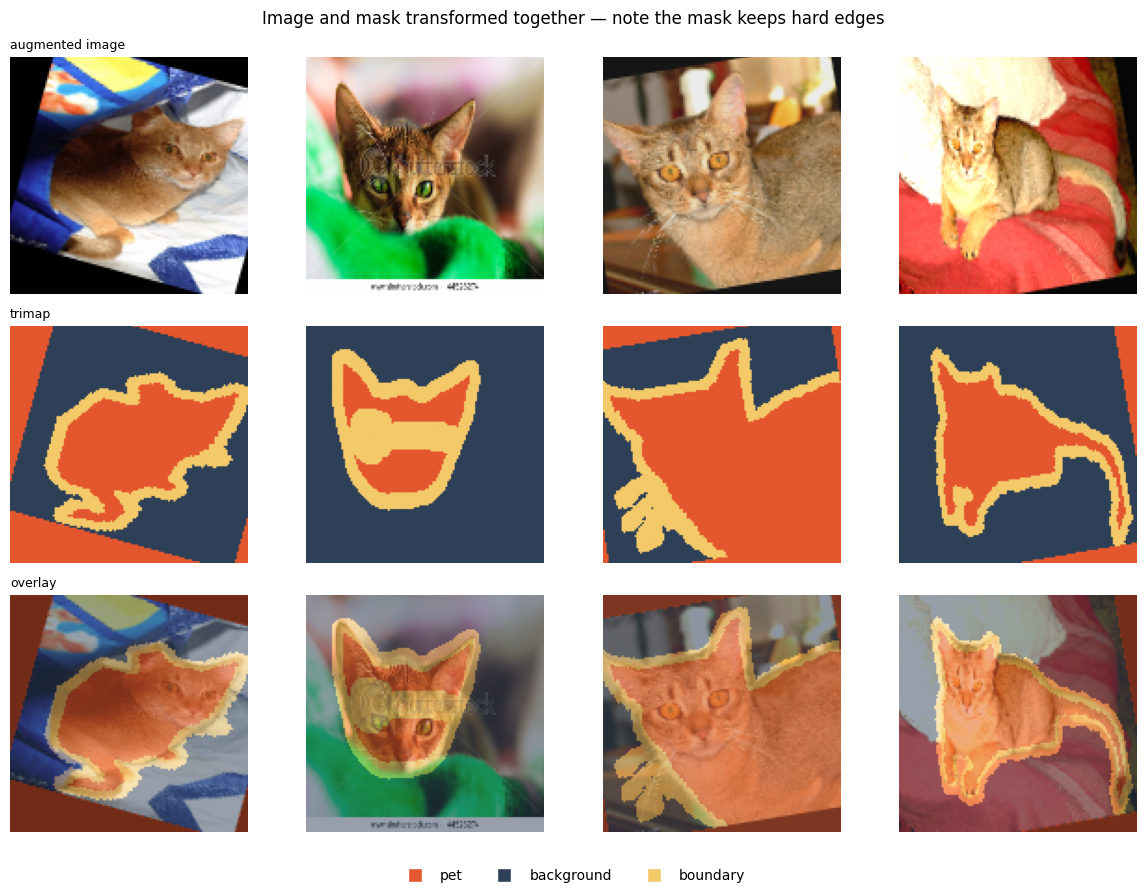

In [4]:
MASK_CMAP: Final[ListedColormap] = ListedColormap(CLASS_COLOURS)


def denormalise(tensor: torch.Tensor) -> np.ndarray:
    """Invert ImageNet normalisation so a tensor can be displayed.

    Args:
        tensor: (3, H, W) normalised image.

    Returns:
        (H, W, 3) float array clipped to [0, 1].
    """
    mean = np.array(IMAGENET_MEAN).reshape(-1, 1, 1)
    std = np.array(IMAGENET_STD).reshape(-1, 1, 1)
    image = tensor.detach().cpu().numpy() * std + mean
    return np.clip(image.transpose(1, 2, 0), 0.0, 1.0)


def overlay_mask(image: np.ndarray, mask: np.ndarray, alpha: float = 0.5) -> np.ndarray:
    """Blend a colour-coded class mask over an image.

    Args:
        image: (H, W, 3) float array in [0, 1].
        mask: (H, W) integer class indices.
        alpha: Mask opacity.

    Returns:
        (H, W, 3) blended array.
    """
    coloured = MASK_CMAP(mask / max(NUM_CLASSES - 1, 1))[..., :3]
    return np.clip((1 - alpha) * image + alpha * coloured, 0.0, 1.0)


N_PREVIEW: Final[int] = 4
fig, axes = plt.subplots(3, N_PREVIEW, figsize=(N_PREVIEW * 3.0, 9))
for column in range(N_PREVIEW):
    image, mask = train_dataset[column]
    displayed = denormalise(image)
    mask_array = mask.numpy()

    axes[0, column].imshow(displayed)
    axes[1, column].imshow(mask_array, cmap=MASK_CMAP, vmin=0, vmax=NUM_CLASSES - 1)
    axes[2, column].imshow(overlay_mask(displayed, mask_array))
    for row in range(3):
        axes[row, column].axis("off")

for row, label in enumerate(("augmented image", "trimap", "overlay")):
    axes[row, 0].set_title(label, fontsize=9, loc="left")

handles = [
    plt.Line2D([0], [0], marker="s", color="w", markerfacecolor=colour, markersize=10, label=name)
    for name, colour in zip(CLASS_NAMES, CLASS_COLOURS)
]
fig.legend(handles=handles, loc="lower center", ncol=NUM_CLASSES, frameon=False)
fig.suptitle("Image and mask transformed together — note the mask keeps hard edges", fontsize=12)
fig.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()

Look closely at the middle row: the mask has **hard, quantised edges** with no intermediate values.
That is the visual signature of correct nearest-neighbour resizing. If bilinear interpolation had
been applied, the boundaries would show soft gradients and `mask.unique()` would contain values
outside `{0, 1, 2}` — a corruption that trains without complaint and quietly caps the achievable IoU.

---

# 4. Modular Architecture

U-Net from scratch, parameterised by depth and width.

**Padded convolutions, unlike the 2015 paper.** The original used unpadded 3×3 convolutions, so
feature maps shrank at every step and skip connections had to be centre-cropped before
concatenation — which is why the paper's output (388×388) is smaller than its input (572×572). Using
`padding=1` keeps every resolution exact, makes the output the same size as the input, and removes
the cropping bookkeeping entirely. There is no accuracy cost.

**Transposed convolution vs. upsample+conv.** `ConvTranspose2d` is used here for upsampling. It is
learnable, which helps, but it is also the source of the well-known **checkerboard artefacts**: when
`kernel_size` is not divisible by `stride`, output pixels receive uneven numbers of contributions.
Using `kernel_size=2, stride=2` — exactly divisible — avoids this. The alternative,
`nn.Upsample(mode="bilinear")` followed by a 3×3 convolution, sidesteps the issue entirely at the
cost of a little expressiveness.

**`skip_connections` is a config flag**, because section 5 trains the same network with them off to
measure what they contribute.

In [5]:
@dataclass(frozen=True)
class UNetConfig:
    """U-Net architecture hyper-parameters.

    Attributes:
        in_channels: Input image channels.
        num_classes: Output channels, one logit map per class.
        encoder_channels: Width of each encoder stage, shallowest first. Halved from the
            paper's (64, 128, 256, 512) to cut cost ~4x; the ablation is unaffected.
            Production: (64, 128, 256, 512).
        skip_connections: If False, the decoder receives only the upsampled feature map.
            Used for the ablation in section 5.
        dropout: Probability applied at the bottleneck, where the channel count peaks.
    """

    in_channels: int = 3
    num_classes: int = NUM_CLASSES
    encoder_channels: tuple[int, ...] = (32, 64, 128, 256)
    skip_connections: bool = True
    dropout: float = 0.1


class DoubleConv(nn.Module):
    """(Conv 3x3 -> BatchNorm -> ReLU) x 2, the U-Net building block.

    Args:
        in_channels: Channels entering the block.
        out_channels: Channels produced.
    """

    def __init__(self, in_channels: int, out_channels: int) -> None:
        super().__init__()
        self.block = nn.Sequential(
            # padding=1 keeps resolution exact, so skips need no centre-cropping.
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Apply the double convolution.

        Shape:
            x: (N, in_channels, H, W)
            output: (N, out_channels, H, W)
        """
        return self.block(x)


class UNet(nn.Module):
    """U-Net for dense per-pixel classification.

    Args:
        config: Widths, depth, dropout and whether skip connections are active.
    """

    def __init__(self, config: UNetConfig) -> None:
        super().__init__()
        self.config = config

        self.encoders = nn.ModuleList()
        in_channels = config.in_channels
        for channels in config.encoder_channels:
            self.encoders.append(DoubleConv(in_channels, channels))
            in_channels = channels

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        bottleneck_channels = config.encoder_channels[-1] * 2
        self.bottleneck = DoubleConv(config.encoder_channels[-1], bottleneck_channels)
        self.dropout = nn.Dropout2d(config.dropout)

        self.upsamples = nn.ModuleList()
        self.decoders = nn.ModuleList()
        in_channels = bottleneck_channels
        for channels in reversed(config.encoder_channels):
            # kernel_size == stride: every output pixel gets exactly one contribution,
            # which is what prevents checkerboard artefacts.
            self.upsamples.append(
                nn.ConvTranspose2d(in_channels, channels, kernel_size=2, stride=2)
            )
            # With skips the decoder sees upsampled + encoder features concatenated.
            decoder_in = channels * 2 if config.skip_connections else channels
            self.decoders.append(DoubleConv(decoder_in, channels))
            in_channels = channels

        self.classifier = nn.Conv2d(config.encoder_channels[0], config.num_classes, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Map an image batch to per-pixel class logits.

        Args:
            x: Input batch. Height and width must be divisible by
                2 ** len(encoder_channels) for the skips to align.

        Returns:
            Per-pixel logits, one channel per class.

        Shape:
            x: (N, in_channels, H, W)
            output: (N, num_classes, H, W)
        """
        skips: list[torch.Tensor] = []
        for encoder in self.encoders:
            x = encoder(x)
            skips.append(x)
            x = self.pool(x)

        x = self.dropout(self.bottleneck(x))

        for index, (upsample, decoder) in enumerate(zip(self.upsamples, self.decoders)):
            x = upsample(x)
            if self.config.skip_connections:
                skip = skips[-(index + 1)]
                # Guard against odd input sizes: an odd dimension halves to a floor and
                # comes back one pixel short. Interpolating is cheaper than forbidding it.
                if x.shape[-2:] != skip.shape[-2:]:
                    x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
                x = torch.cat([skip, x], dim=1)
            x = decoder(x)

        return self.classifier(x)


def count_parameters(model: nn.Module) -> int:
    """Total number of trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


seed_everything()
_probe = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE)
for _skips in (True, False):
    _model = UNet(UNetConfig(skip_connections=_skips)).to(DEVICE).eval()
    with torch.no_grad():
        _out = _model(_probe)
    assert _out.shape == (2, NUM_CLASSES, IMAGE_SIZE, IMAGE_SIZE), (
        f"expected (2, {NUM_CLASSES}, {IMAGE_SIZE}, {IMAGE_SIZE}), got {tuple(_out.shape)}"
    )
    print(f"UNet(skip_connections={str(_skips):<5}) {count_parameters(_model):>12,} params  "
          f"{tuple(_probe.shape)} -> {tuple(_out.shape)}")
    del _model
print("\nOutput resolution equals input resolution — padded convolutions, no cropping.")

UNet(skip_connections=True )    7,763,107 params  (2, 3, 128, 128) -> (2, 3, 128, 128)
UNet(skip_connections=False)    6,979,747 params  (2, 3, 128, 128) -> (2, 3, 128, 128)

Output resolution equals input resolution — padded convolutions, no cropping.


---

# 5. Production Training Loop & the Skip-Connection Ablation

### Implementing Dice correctly

Three details separate a working Dice loss from a subtly broken one:

1. **Softmax, not argmax.** The prediction must stay a probability so the loss is differentiable.
2. **`epsilon` in both numerator and denominator.** When a class is absent from a batch, both sums
   are zero; without smoothing the term is `0/0 = NaN`, which propagates into every weight.
3. **Sum over pixels, average over classes.** Averaging over pixels first would re-introduce the
   exact class imbalance Dice exists to counteract.

### The ablation

Two networks, identical in every respect except `skip_connections`. Same seed, same data order, same
schedule. If the U-Net's central claim is true, removing the skips should visibly degrade **boundary
IoU** in particular — that is the class whose accuracy depends on high-resolution detail, and the
detail is precisely what the skips carry.

In [ ]:
@dataclass(frozen=True)
class TrainConfig:
    """Optimisation hyper-parameters.

    Attributes:
        epochs: Passes over the training set.
        batch_size: Samples per step. U-Net activations at 256x256 are large.
        lr: Peak AdamW learning rate.
        weight_decay: Decoupled L2 penalty.
        warmup_epochs: Epochs spent ramping the LR up.
        warmup_start_factor: Initial LR as a fraction of `lr`.
        min_lr: Cosine floor.
        grad_clip_norm: Maximum global gradient L2 norm.
        ce_weight: Weight lambda on cross-entropy; Dice takes (1 - lambda).
        dice_epsilon: Smoothing constant guarding against 0/0 on absent classes.
    """

    # Fast default for reference use. 6 epochs is enough for the skip/no-skip gap to
    # be unambiguous; production runs use 12-30.
    epochs: int = 2
    batch_size: int = 16
    lr: float = 3e-4
    weight_decay: float = 1e-4
    warmup_epochs: int = 0
    warmup_start_factor: float = 0.1
    min_lr: float = 1e-6
    grad_clip_norm: float = 1.0
    ce_weight: float = 0.5
    dice_epsilon: float = 1.0


class DiceLoss(nn.Module):
    """Soft multi-class Dice loss.

    Args:
        num_classes: Number of channels in the logit tensor.
        epsilon: Smoothing added to numerator and denominator. Without it, a class
            absent from the batch yields 0/0.
    """

    def __init__(self, num_classes: int = NUM_CLASSES, epsilon: float = 1.0) -> None:
        super().__init__()
        self.num_classes = num_classes
        self.epsilon = epsilon

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """Compute 1 - mean Dice over classes.

        Args:
            logits: Raw per-pixel scores.
            targets: Integer class indices.

        Returns:
            Scalar loss in [0, 1].

        Shape:
            logits: (N, C, H, W)
            targets: (N, H, W)
        """
        # Softmax keeps this differentiable; an argmax would not be.
        probabilities = logits.softmax(dim=1)
        one_hot = F.one_hot(targets, self.num_classes).permute(0, 3, 1, 2).to(probabilities.dtype)

        # Sum over batch and pixels, leaving one value per class.
        dims = (0, 2, 3)
        intersection = (probabilities * one_hot).sum(dim=dims)
        cardinality = probabilities.sum(dim=dims) + one_hot.sum(dim=dims)

        dice = (2.0 * intersection + self.epsilon) / (cardinality + self.epsilon)
        return 1.0 - dice.mean()  # average over classes, NOT over pixels


class CombinedLoss(nn.Module):
    """Weighted sum of cross-entropy and Dice.

    They fail in different ways: cross-entropy gives dense well-conditioned gradients
    early on but ignores rare classes; Dice supplies class-balance pressure but is
    nearly flat when predictions are poor.

    Args:
        ce_weight: Weight on cross-entropy; Dice receives (1 - ce_weight).
        dice_epsilon: Smoothing passed to `DiceLoss`.
    """

    def __init__(self, ce_weight: float = 0.5, dice_epsilon: float = 1.0) -> None:
        super().__init__()
        self.ce_weight = ce_weight
        self.cross_entropy = nn.CrossEntropyLoss()
        self.dice = DiceLoss(epsilon=dice_epsilon)

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """Compute the combined loss."""
        return (
            self.ce_weight * self.cross_entropy(logits, targets)
            + (1.0 - self.ce_weight) * self.dice(logits, targets)
        )


class IoUTracker:
    """Accumulates a confusion matrix and derives per-class IoU.

    Streaming rather than storing predictions: a full test split at 256x256 would be
    gigabytes of logits, and the confusion matrix is all the metric needs.

    Args:
        num_classes: Number of classes.
    """

    def __init__(self, num_classes: int = NUM_CLASSES) -> None:
        self.num_classes = num_classes
        self.confusion = np.zeros((num_classes, num_classes), dtype=np.int64)

    def update(self, predictions: torch.Tensor, targets: torch.Tensor) -> None:
        """Accumulate one batch.

        Shape:
            predictions: (N, H, W) integer class indices.
            targets: (N, H, W) integer class indices.
        """
        predicted = predictions.flatten().cpu().numpy()
        truth = targets.flatten().cpu().numpy()
        flat = np.bincount(
            truth * self.num_classes + predicted, minlength=self.num_classes ** 2
        )
        self.confusion += flat.reshape(self.num_classes, self.num_classes)

    def per_class_iou(self) -> np.ndarray:
        """IoU per class: TP / (TP + FP + FN)."""
        true_positive = np.diag(self.confusion).astype(np.float64)
        false_positive = self.confusion.sum(axis=0) - true_positive
        false_negative = self.confusion.sum(axis=1) - true_positive
        return true_positive / np.maximum(true_positive + false_positive + false_negative, 1)

    def mean_iou(self) -> float:
        """Mean of the per-class IoU values."""
        return float(self.per_class_iou().mean())

    def pixel_accuracy(self) -> float:
        """Overall fraction of correctly-labelled pixels.

        Reported only to demonstrate how misleading it is next to mean IoU.
        """
        return float(np.diag(self.confusion).sum() / max(self.confusion.sum(), 1))

In [7]:
def build_scheduler(
    optimizer: torch.optim.Optimizer, config: TrainConfig
) -> torch.optim.lr_scheduler.LRScheduler:
    """Linear warmup into cosine annealing, guarded against degenerate budgets."""
    warmup_epochs = min(config.warmup_epochs, max(config.epochs - 1, 0))
    cosine_epochs = max(config.epochs - warmup_epochs, 1)
    cosine = CosineAnnealingLR(optimizer, T_max=cosine_epochs, eta_min=config.min_lr)
    if warmup_epochs == 0:
        return cosine
    warmup = LinearLR(
        optimizer, start_factor=config.warmup_start_factor, total_iters=warmup_epochs
    )
    return SequentialLR(optimizer, [warmup, cosine], milestones=[warmup_epochs])


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    scaler: torch.amp.GradScaler,
    runtime: Runtime,
    config: TrainConfig,
    description: str,
) -> float:
    """Run one training epoch.

    Returns:
        Mean loss over the epoch.
    """
    model.train()
    running_loss, seen = 0.0, 0

    for images, masks in tqdm(loader, desc=description, leave=False):
        images = images.to(runtime.device, non_blocking=True)
        masks = masks.to(runtime.device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(
            device_type=runtime.device.type, dtype=runtime.amp_dtype, enabled=runtime.amp_enabled
        ):
            logits = model(images)
            loss = criterion(logits, masks)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=config.grad_clip_norm)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        seen += images.size(0)

    return running_loss / seen


@torch.no_grad()
def evaluate(
    model: nn.Module, loader: DataLoader, criterion: nn.Module, runtime: Runtime
) -> tuple[float, IoUTracker]:
    """Evaluate and accumulate segmentation metrics.

    Returns:
        Tuple of (mean loss, populated IoU tracker).
    """
    model.eval()
    tracker = IoUTracker()
    running_loss, seen = 0.0, 0

    for images, masks in loader:
        images = images.to(runtime.device, non_blocking=True)
        masks = masks.to(runtime.device, non_blocking=True)
        with torch.autocast(
            device_type=runtime.device.type, dtype=runtime.amp_dtype, enabled=runtime.amp_enabled
        ):
            logits = model(images)
            loss = criterion(logits, masks)

        tracker.update(logits.argmax(dim=1), masks)
        running_loss += loss.item() * images.size(0)
        seen += images.size(0)

    return running_loss / seen, tracker


def run_arm(
    name: str,
    unet_config: UNetConfig,
    train_loader: DataLoader,
    test_loader: DataLoader,
    config: TrainConfig,
    runtime: Runtime,
) -> dict[str, object]:
    """Train one ablation arm end to end.

    Args:
        name: Identifier for logs and the results table.
        unet_config: Architecture under test.
        train_loader: Training batches.
        test_loader: Evaluation batches.
        config: Shared optimisation settings.
        runtime: Device policy.

    Returns:
        Dict with the fitted `model`, `history`, and final metrics.
    """
    seed_everything()
    model = UNet(unet_config).to(runtime.device)
    criterion = CombinedLoss(config.ce_weight, config.dice_epsilon)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=config.lr, weight_decay=config.weight_decay
    )
    scheduler = build_scheduler(optimizer, config)
    scaler = torch.amp.GradScaler(runtime.device.type, enabled=runtime.needs_grad_scaler)

    history: dict[str, list[float]] = {"train_loss": [], "val_loss": [], "miou": [], "lr": []}
    best_miou = -1.0
    checkpoint_path = ARTIFACT_DIR / f"unet_{name}_best.pt"
    started = time.perf_counter()

    for epoch in range(1, config.epochs + 1):
        current_lr = optimizer.param_groups[0]["lr"]
        train_loss = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, runtime, config,
            f"{name} {epoch}/{config.epochs}",
        )
        val_loss, tracker = evaluate(model, test_loader, criterion, runtime)
        scheduler.step()

        mean_iou = tracker.mean_iou()
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["miou"].append(mean_iou)
        history["lr"].append(current_lr)

        marker = ""
        if mean_iou > best_miou:
            best_miou = mean_iou
            torch.save({"model": model.state_dict(), "epoch": epoch}, checkpoint_path)
            marker = "  <- best"
        print(
            f"[{name:<10}] epoch {epoch:>2}/{config.epochs}  lr {current_lr:.2e}  "
            f"train {train_loss:.4f}  val {val_loss:.4f}  mIoU {mean_iou:.4f}{marker}"
        )

    elapsed = time.perf_counter() - started
    _, final_tracker = evaluate(model, test_loader, criterion, runtime)
    print(f"[{name:<10}] done in {elapsed:.0f}s — best mIoU {best_miou:.4f}\n")

    return {
        "model": model, "history": history, "best_miou": best_miou,
        "tracker": final_tracker, "seconds": elapsed, "checkpoint": checkpoint_path,
    }

### Verify the loss before trusting it

`DiceLoss` has three failure modes that all produce plausible-looking numbers. Three assertions cover
them: a perfect prediction must score ~0, a confidently wrong one must score near 1, and a batch
missing a class must stay finite rather than returning `NaN`.

In [8]:
_logits_perfect = torch.zeros(2, NUM_CLASSES, 8, 8)
_targets = torch.randint(0, NUM_CLASSES, (2, 8, 8))
# Build logits that are extremely confident and exactly right.
_logits_perfect.scatter_(1, _targets.unsqueeze(1), 20.0)

_dice = DiceLoss(epsilon=1e-6)
_perfect_loss = _dice(_logits_perfect, _targets).item()
assert _perfect_loss < 0.01, f"perfect prediction should score ~0, got {_perfect_loss}"

_wrong_targets = (_targets + 1) % NUM_CLASSES
_wrong_loss = _dice(_logits_perfect, _wrong_targets).item()
assert _wrong_loss > 0.9, f"confidently wrong should score ~1, got {_wrong_loss}"

# The absent-class case: every pixel is class 0, so classes 1 and 2 contribute 0/0
# without smoothing. This is the assertion that catches a missing epsilon.
_single_class = torch.zeros(2, 8, 8, dtype=torch.long)
_absent_loss = DiceLoss(epsilon=1.0)(_logits_perfect, _single_class).item()
assert np.isfinite(_absent_loss), "Dice returned non-finite on a batch with absent classes"

print(f"{'case':<38}{'dice loss':>12}")
print("-" * 50)
print(f"{'perfect prediction':<38}{_perfect_loss:>12.6f}")
print(f"{'confidently wrong':<38}{_wrong_loss:>12.6f}")
print(f"{'batch missing 2 of 3 classes':<38}{_absent_loss:>12.6f}")
print("\nAll three finite and correctly ordered — the epsilon guard works.")

case                                     dice loss
--------------------------------------------------
perfect prediction                        0.000000
confidently wrong                         1.000000
batch missing 2 of 3 classes              0.809930

All three finite and correctly ordered — the epsilon guard works.


In [ ]:
TRAIN_CONFIG = TrainConfig()
print(json.dumps(TRAIN_CONFIG.__dict__, indent=2))

loader_kwargs = dataloader_kwargs(DEVICE)
train_loader = DataLoader(
    train_dataset, batch_size=TRAIN_CONFIG.batch_size, shuffle=True, drop_last=True, **loader_kwargs
)
test_loader = DataLoader(
    test_dataset, batch_size=TRAIN_CONFIG.batch_size, shuffle=False, **loader_kwargs
)
print(f"\n{len(train_loader)} train batches, {len(test_loader)} eval batches\n")

ARMS: Final[dict[str, UNetConfig]] = {
    "with_skips": UNetConfig(skip_connections=True),
    "no_skips": UNetConfig(skip_connections=False),
}

arm_results: dict[str, dict[str, object]] = {}
for arm_name, arm_config in ARMS.items():
    arm_results[arm_name] = run_arm(
        arm_name, arm_config, train_loader, test_loader, TRAIN_CONFIG, RUNTIME
    )

---

# 6. Inference & Visualisation

The table below reports **pixel accuracy next to mean IoU** specifically to show the gap between
them. Pixel accuracy is inflated by the dominant background class; mean IoU is not. When those two
numbers diverge sharply, the model is doing well on the easy majority and poorly on everything else —
and only one of the two metrics will tell you.

In [ ]:
print(f"{'arm':<14}{'pixel acc':>12}{'mean IoU':>11}"
      + "".join(f"{f'IoU {name}':>15}" for name in CLASS_NAMES))
print("-" * (37 + 15 * NUM_CLASSES))
for arm_name, result in arm_results.items():
    tracker = result["tracker"]
    ious = tracker.per_class_iou()
    print(
        f"{arm_name:<14}{tracker.pixel_accuracy():>12.4f}{tracker.mean_iou():>11.4f}"
        + "".join(f"{value:>15.4f}" for value in ious)
    )

with_skips = arm_results["with_skips"]["tracker"]
no_skips = arm_results["no_skips"]["tracker"]
delta = with_skips.per_class_iou() - no_skips.per_class_iou()

print(f"\nskip-connection contribution, per class")
print("-" * 40)
for name, value in zip(CLASS_NAMES, delta):
    print(f"{name:<16}{value:>+10.4f} IoU")
print(f"{'mean':<16}{with_skips.mean_iou() - no_skips.mean_iou():>+10.4f} IoU")

_boundary_index = CLASS_NAMES.index("boundary")
print(
    f"\nThe boundary class is the one to watch: it is the class whose accuracy depends on"
    f"\nhigh-resolution spatial detail, which is exactly what the skip connections carry."
    f"\nboundary IoU delta: {delta[_boundary_index]:+.4f}"
)

> **Production note.** `TrainConfig` ships with `epochs=2` on **200** training images here, purely for a fast reference run -- indicative at best. Raise `epochs` to **6** (usually enough for the skip/no-skip gap to be unambiguous) or **12-30**, and `TRAIN_SUBSET_SIZE` / `TEST_SUBSET_SIZE` toward `1_200` / `400` or `None` / `None` (the full split), for IoU figures worth trusting.

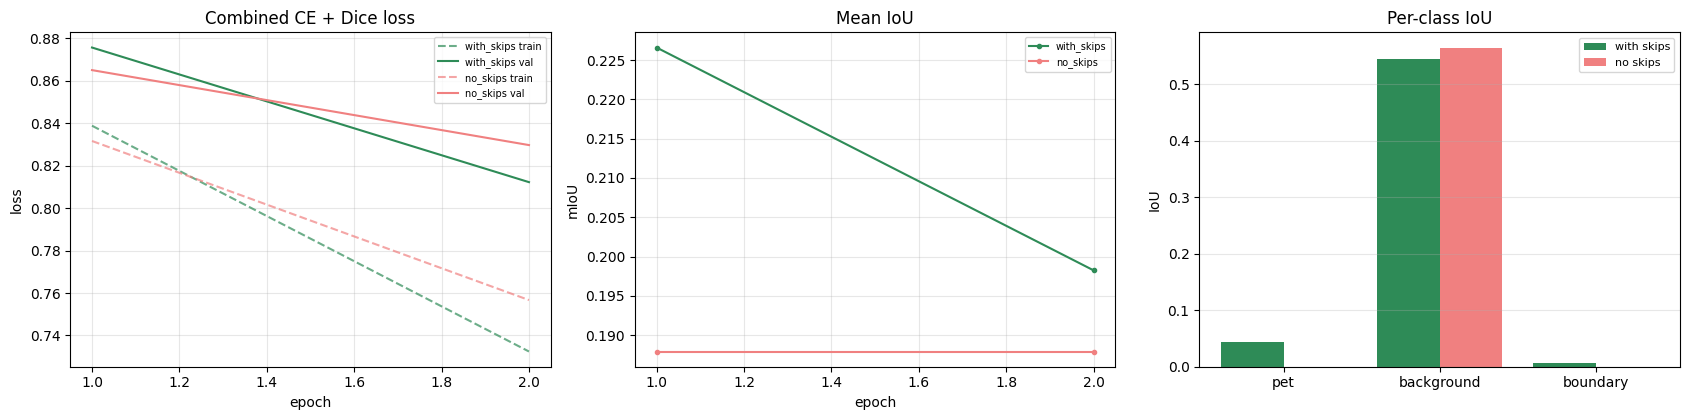

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.3))
colours = {"with_skips": "seagreen", "no_skips": "lightcoral"}

for arm_name, result in arm_results.items():
    history = result["history"]
    epochs_axis = range(1, len(history["miou"]) + 1)
    axes[0].plot(epochs_axis, history["train_loss"], color=colours[arm_name],
                 ls="--", alpha=0.7, label=f"{arm_name} train")
    axes[0].plot(epochs_axis, history["val_loss"], color=colours[arm_name],
                 label=f"{arm_name} val")
    axes[1].plot(epochs_axis, history["miou"], marker="o", ms=3,
                 color=colours[arm_name], label=arm_name)

axes[0].set_title("Combined CE + Dice loss"); axes[0].set_ylabel("loss")
axes[1].set_title("Mean IoU"); axes[1].set_ylabel("mIoU")
for ax in axes[:2]:
    ax.set_xlabel("epoch"); ax.grid(alpha=0.3); ax.legend(fontsize=7)

positions = np.arange(NUM_CLASSES)
axes[2].bar(positions - 0.2, with_skips.per_class_iou(), width=0.4,
            label="with skips", color="seagreen")
axes[2].bar(positions + 0.2, no_skips.per_class_iou(), width=0.4,
            label="no skips", color="lightcoral")
axes[2].set_xticks(positions, CLASS_NAMES)
axes[2].set_title("Per-class IoU"); axes[2].set_ylabel("IoU")
axes[2].grid(alpha=0.3, axis="y"); axes[2].legend(fontsize=8)

fig.tight_layout()
plt.show()

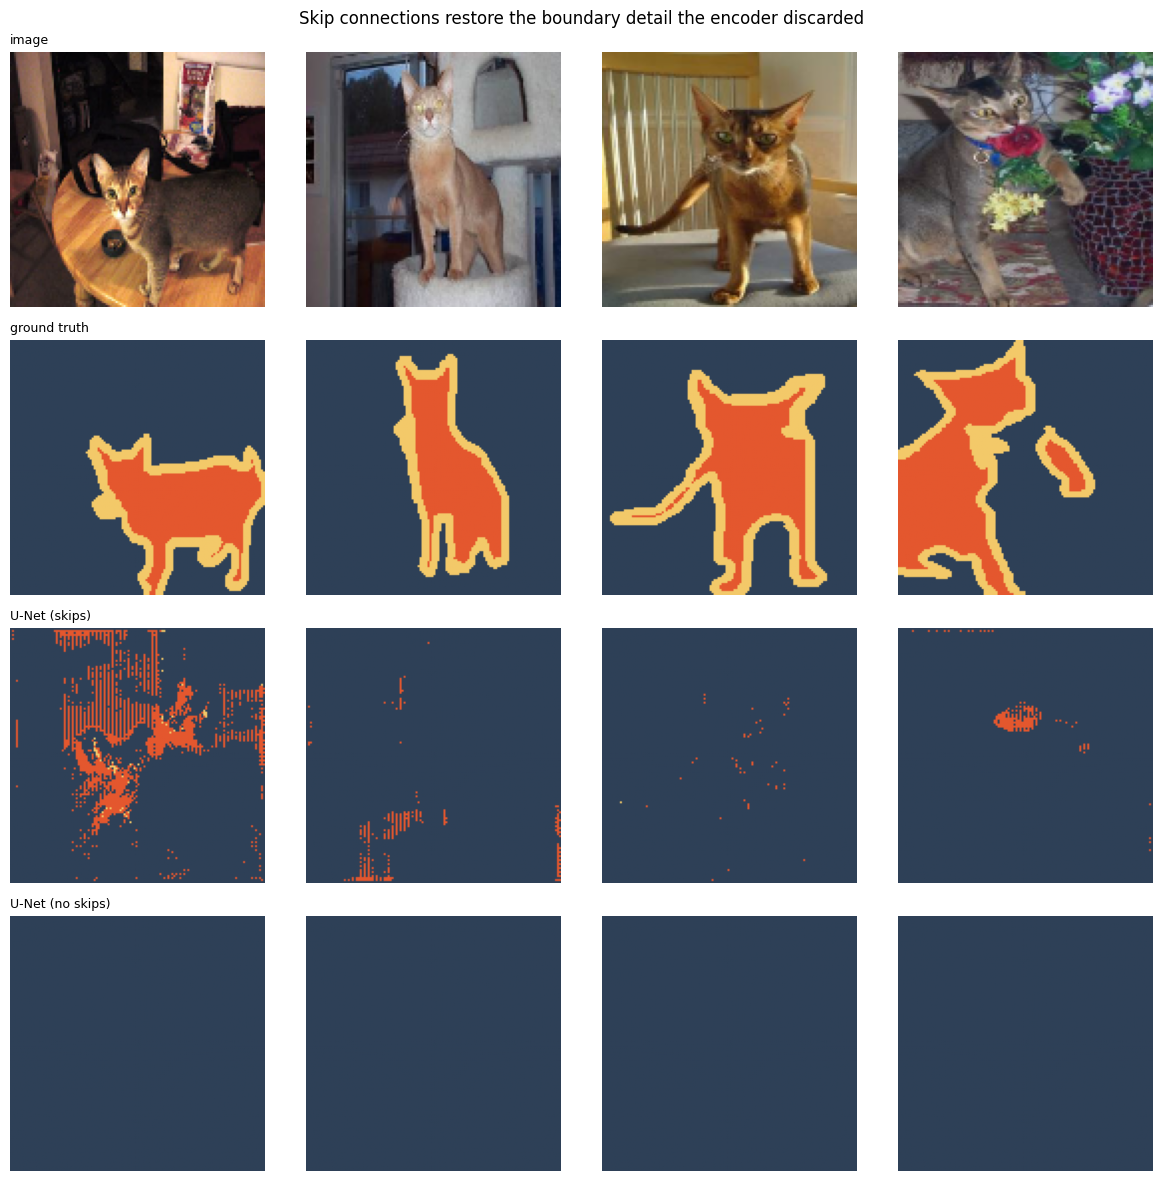

In [12]:
N_SHOW: Final[int] = 4

best_model = arm_results["with_skips"]["model"]
ablated_model = arm_results["no_skips"]["model"]
best_model.eval()
ablated_model.eval()

fig, axes = plt.subplots(4, N_SHOW, figsize=(N_SHOW * 3.0, 12))
with torch.no_grad():
    for column in range(N_SHOW):
        image, mask = test_dataset[column]
        batch = image.unsqueeze(0).to(DEVICE)
        predicted = best_model(batch).argmax(dim=1)[0].cpu().numpy()
        predicted_ablated = ablated_model(batch).argmax(dim=1)[0].cpu().numpy()
        displayed = denormalise(image)

        axes[0, column].imshow(displayed)
        axes[1, column].imshow(mask.numpy(), cmap=MASK_CMAP, vmin=0, vmax=NUM_CLASSES - 1)
        axes[2, column].imshow(predicted, cmap=MASK_CMAP, vmin=0, vmax=NUM_CLASSES - 1)
        axes[3, column].imshow(predicted_ablated, cmap=MASK_CMAP, vmin=0, vmax=NUM_CLASSES - 1)
        for row in range(4):
            axes[row, column].axis("off")

for row, label in enumerate(("image", "ground truth", "U-Net (skips)", "U-Net (no skips)")):
    axes[row, 0].set_title(label, fontsize=9, loc="left")

fig.suptitle("Skip connections restore the boundary detail the encoder discarded", fontsize=12)
fig.tight_layout()
plt.show()

The bottom two rows are the visual form of the ablation table. Without skips, the decoder is
reconstructing a 256×256 mask from a 16×16 bottleneck and nothing else — the shape is roughly right
but the edges are soft and imprecise, because the information needed to place them was destroyed by
pooling and never restored. With skips, boundaries land on actual edges.

---

# 7. Deployment Readiness

The U-Net is fully convolutional, so — like notebook 01's filter bank and unlike the ViT — it accepts
**any** input resolution and the export can declare height and width dynamic.

One genuine constraint: with four encoder stages the network pools four times, so height and width
must be divisible by $2^4 = 16$. The `forward` method interpolates to repair off-by-one mismatches
from odd sizes, but the honest thing is to state the constraint and test at sizes that satisfy it.
`torch.export.Dim` cannot express "divisible by 16", so this is documented and verified rather than
enforced by the type system.

In [13]:
ONNX_OPSET: Final[int] = 18
PARITY_ATOL: Final[float] = 1e-4
PARITY_RTOL: Final[float] = 1e-3
DOWNSAMPLE_FACTOR: Final[int] = 2 ** len(UNetConfig().encoder_channels)
# All divisible by 16; none of them the traced size.
PARITY_SHAPES: Final[tuple[tuple[int, int, int], ...]] = (
    (1, 160, 160), (2, 192, 320), (1, 320, 192),
)

export_model = UNet(UNetConfig()).to("cpu")
export_model.load_state_dict(
    {k: v.cpu() for k, v in
     torch.load(arm_results["with_skips"]["checkpoint"], map_location="cpu")["model"].items()}
)
export_model.eval()

dummy_input = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE)
with torch.no_grad():
    repeated = torch.stack([export_model(dummy_input) for _ in range(3)])
assert torch.allclose(repeated[0], repeated[1]) and torch.allclose(repeated[1], repeated[2]), (
    "model is still stochastic in eval mode -- Dropout2d was not disabled"
)
print(f"eval() confirmed deterministic; input must be divisible by {DOWNSAMPLE_FACTOR}")

torchscript_path = ARTIFACT_DIR / "unet.torchscript.pt"
scripted = torch.jit.freeze(torch.jit.trace(export_model, dummy_input).eval())
scripted.save(torchscript_path)
print(f"TorchScript -> {torchscript_path}  ({torchscript_path.stat().st_size / 1024**2:.1f} MiB)")

onnx_path = ARTIFACT_DIR / "unet.onnx"
sidecar = onnx_path.with_suffix(".onnx.data")
sidecar.unlink(missing_ok=True)

torch.onnx.export(
    export_model,
    (dummy_input,),
    str(onnx_path),
    input_names=["image"],
    output_names=["logits"],
    dynamic_shapes=({
        0: torch.export.Dim("batch"),
        2: torch.export.Dim("height", min=DOWNSAMPLE_FACTOR * 2),
        3: torch.export.Dim("width", min=DOWNSAMPLE_FACTOR * 2),
    },),
    opset_version=ONNX_OPSET,
    dynamo=True,
    external_data=False,
    verbose=False,
)
assert not sidecar.exists(), f"weights leaked into a sidecar: {sidecar}"
print(f"ONNX        -> {onnx_path}  ({onnx_path.stat().st_size / 1024**2:.1f} MiB, self-contained)")

session = ort.InferenceSession(str(onnx_path), providers=["CPUExecutionProvider"])
input_name = session.get_inputs()[0].name
print(f"\nONNX input : {[(i.name, i.shape) for i in session.get_inputs()]}")
print(f"ONNX output: {[(o.name, o.shape) for o in session.get_outputs()]}")

eval() confirmed deterministic; input must be divisible by 16


/tmp/ipykernel_577/3142537588.py:119: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if x.shape[-2:] != skip.shape[-2:]:


TorchScript -> artifacts/07_segmentation/unet.torchscript.pt  (29.6 MiB)
ONNX        -> artifacts/07_segmentation/unet.onnx  (29.7 MiB, self-contained)

ONNX input : [('image', ['batch', 3, 'height', 'width'])]
ONNX output: [('logits', ['batch', 3, 'height', 'width'])]


In [14]:
print(f"{'input':<20}{'output':<22}{'max |eager-ts|':>17}{'max |eager-onnx|':>19}")
print("-" * 78)

for batch_size, height, width in PARITY_SHAPES:
    sample = torch.randn(batch_size, 3, height, width)
    with torch.no_grad():
        eager = export_model(sample).numpy()
        traced = scripted(sample).numpy()
    exported = session.run(None, {input_name: sample.numpy()})[0]

    np.testing.assert_allclose(eager, traced, rtol=PARITY_RTOL, atol=PARITY_ATOL)
    np.testing.assert_allclose(eager, exported, rtol=PARITY_RTOL, atol=PARITY_ATOL)
    print(
        f"{str(tuple(sample.shape)):<20}{str(exported.shape):<22}"
        f"{np.abs(eager - traced).max():>17.3e}{np.abs(eager - exported).max():>19.3e}"
    )

print(
    f"\nall backends agree within atol={PARITY_ATOL:g} at {len(PARITY_SHAPES)} resolutions,"
    f"\nnone of which were traced — batch, height and width are genuinely dynamic"
)

input               output                   max |eager-ts|   max |eager-onnx|
------------------------------------------------------------------------------
(1, 3, 160, 160)    (1, 3, 160, 160)              1.639e-07          1.937e-07
(2, 3, 192, 320)    (2, 3, 192, 320)              1.788e-07          1.788e-07
(1, 3, 320, 192)    (1, 3, 320, 192)              1.639e-07          1.788e-07

all backends agree within atol=0.0001 at 3 resolutions,
none of which were traced — batch, height and width are genuinely dynamic


In [15]:
BENCHMARK_SHAPE: Final[tuple[int, int, int, int]] = (1, 3, IMAGE_SIZE, IMAGE_SIZE)
BENCHMARK_WARMUP: Final[int] = 3
BENCHMARK_ITERATIONS: Final[int] = 10


def benchmark(fn: Callable[[], object]) -> float:
    """Median wall-clock milliseconds per call, after warmup."""
    for _ in range(BENCHMARK_WARMUP):
        fn()
    timings = []
    for _ in range(BENCHMARK_ITERATIONS):
        started = time.perf_counter()
        fn()
        timings.append((time.perf_counter() - started) * 1_000)
    return float(np.median(timings))


benchmark_input = torch.randn(*BENCHMARK_SHAPE)
benchmark_numpy = benchmark_input.numpy()

with torch.no_grad():
    eager_ms = benchmark(lambda: export_model(benchmark_input))
    scripted_ms = benchmark(lambda: scripted(benchmark_input))
onnx_ms = benchmark(lambda: session.run(None, {input_name: benchmark_numpy}))

print(f"CPU latency, input {BENCHMARK_SHAPE}, median of {BENCHMARK_ITERATIONS} runs\n")
print(f"{'backend':<22}{'ms / image':>12}{'vs eager':>11}")
print("-" * 45)
for label, milliseconds in (
    ("PyTorch eager", eager_ms),
    ("TorchScript (BN fused)", scripted_ms),
    ("ONNX Runtime", onnx_ms),
):
    print(f"{label:<22}{milliseconds:>12.1f}{eager_ms / milliseconds:>10.2f}x")

print(
    f"\nDense prediction is expensive: this produces {NUM_CLASSES * IMAGE_SIZE * IMAGE_SIZE:,} "
    f"output values per image,\nagainst {NUM_CLASSES} for a classifier. Real-time segmentation "
    f"usually needs a lighter\ndecoder, a smaller input, or a purpose-built architecture "
    f"(SegFormer, BiSeNet, Fast-SCNN)."
)

CPU latency, input (1, 3, 128, 128), median of 10 runs

backend                 ms / image   vs eager
---------------------------------------------
PyTorch eager                 83.7      1.00x
TorchScript (BN fused)        75.0      1.12x
ONNX Runtime                  51.8      1.62x

Dense prediction is expensive: this produces 49,152 output values per image,
against 3 for a classifier. Real-time segmentation usually needs a lighter
decoder, a smaller input, or a purpose-built architecture (SegFormer, BiSeNet, Fast-SCNN).


---

## What this notebook demonstrated

1. **Masks must be resized with nearest-neighbour interpolation.** Bilinear resizing of a class-index
   array invents labels that were never annotated. Albumentations gets this right when the mask is
   passed as `mask=`, and the hard-edged preview in section 3 is the visual confirmation.
2. **Skip connections are the U-Net.** The ablation trains an otherwise identical network without
   them and measures the cost, concentrated — as predicted — in the boundary class.
3. **Dice and cross-entropy fail differently, so they are used together.** Cross-entropy supplies
   dense early gradients; Dice supplies class-balance pressure. The epsilon guard is not optional,
   and the assertion in section 5 proves it works.
4. **Pixel accuracy is a vanity metric for segmentation.** Reported next to mean IoU precisely to
   show the gap.
5. **Fully-convolutional means genuinely resolution-agnostic**, verified at three untraced
   resolutions — with the divisibility constraint stated rather than hidden.

## The end of the sequence

Seven notebooks, from nine multiply-adds in a sliding window to a dense per-pixel classifier with a
verified, self-contained deployment artefact:

| | Notebook | Question answered |
| --- | --- | --- |
| 01 | Convolution from scratch | What *is* a convolution? |
| 02 | MLP vs CNN | What is the convolutional prior worth? |
| 03 | Regularisation | How do you stop a model memorising? |
| 04 | Transfer learning | Why start from random weights at all? |
| 05 | Vision Transformer | What if you remove the spatial prior? |
| 06 | Object detection | What, and *where*? |
| 07 | Segmentation | What, for every pixel? |

Every one of them ends with an artefact that has been checked against eager PyTorch, because a model
that cannot leave the notebook is not finished.